In [2]:
import pandas as pd
df = pd.read_csv('nn5_daily_dataset_without_missing_values.tsf', sep=';')

In [3]:
df = df[18:]

In [4]:
df.shape

(111, 1)

In [5]:
df.iloc[2,0].split(':')

['T3',
 '1996-03-18 00-00-00',
 '5.640589569161,14.3990929705215,24.4189342403628,28.7840136054422,20.6207482993197,13.8038548752834,11.5362811791383,10.7426303854875,14.8242630385488,25.2125850340136,35.1332199546485,24.7874149659864,12.8968253968254,15.1218820861678,11.9047619047619,17.7295918367347,36.1394557823129,22.7040816326531,24.9433106575964,2.56519274376417,0,11.437074829932,11.1819727891156,17.9138321995465,20.8758503401361,21.0459183673469,12.7692743764172,10.7284580498866,8.95691609977324,14.9234693877551,23.2426303854875,29.3934240362812,23.8095238095238,12.0748299319728,3.51473922902494,8.64512471655329,13.9739229024943,22.9308390022676,36.6496598639456,22.859977324263,14.030612244898,14.3707482993197,11.7063492063492,17.5028344671202,20.124716553288,34.1128117913832,25.4960317460317,12.0748299319728,27.0975056689342,12.1740362811791,14.3424036281179,19.06179138322,35.7993197278912,22.7749433106576,4.8469387755102,7.12868480725624,10.969387755102,18.3390022675737,23.143

In [6]:
len(df.iloc[18,0].split(':')[2].split(','))

791

In [7]:
len(df.iloc[18,0].split(':'))

3

In [8]:
import pandas as pd
import numpy as np

def load_tsf_custom(file_path):
    new_data = {}

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()

            if not line or line.startswith('#') or line.startswith('@'):
                continue

            # The data format is: ATMname:StartDate:Value1,Value2,Value3...
            parts = line.split(':')
            if len(parts) >= 3:
                series_name = parts[0]
                start_date = parts[1].split(' ')[0] # Extract just the '1996-03-18' part
                values_str = parts[2]


                # (handle '?' which is sometimes used for missing values in TSF)
                values = [float(val) if val != '?' else np.nan for val in values_str.split(',')]

                new_data[series_name] = values


    df = pd.DataFrame(new_data)

    # NN5 dataset starts on 1996-03-18 with daily frequency
    df.index = pd.date_range(start=start_date, periods=len(df), freq='D')

    return df

df_nn5 = load_tsf_custom('nn5_daily_dataset_without_missing_values.tsf')

# Show the first 5 rows
df_nn5

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T102,T103,T104,T105,T106,T107,T108,T109,T110,T111
1996-03-18,13.407029,11.550454,5.640590,13.180272,9.778912,9.240363,14.937642,2.891156,7.341270,10.289116,...,12.910998,3.670635,14.200680,9.778912,7.695578,8.857710,9.297052,10.416667,11.635488,8.337717
1996-03-19,14.725057,13.591270,14.399093,8.446712,10.813492,11.635488,16.284014,12.358277,9.155329,12.712585,...,15.447846,3.557256,7.128685,11.564626,5.541383,11.380385,12.429138,14.923469,10.586735,9.876381
1996-03-20,20.564059,15.036848,24.418934,19.515306,21.612812,12.103175,16.666667,16.383220,10.586735,14.441610,...,20.372732,4.846939,24.900794,13.803855,16.312358,11.777211,13.251134,25.864512,12.570862,16.320358
1996-03-21,34.708050,21.570295,28.784014,28.883220,38.520408,21.414399,23.568594,30.158730,12.500000,19.401927,...,26.296769,7.086168,26.261338,23.341837,23.951247,18.820862,24.815760,37.996032,17.517007,22.553919
1996-03-22,26.629819,19.444444,20.620748,19.472789,24.744898,24.674036,26.303855,31.179138,7.157029,21.541950,...,33.056973,5.357143,32.893991,23.129252,24.064626,24.305556,19.231859,33.290816,24.291383,18.095739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998-05-13,44.373583,20.663265,36.522109,25.028345,20.833333,19.501134,15.490363,18.551587,8.829365,22.562358,...,20.464853,8.602608,31.519274,14.937642,17.517007,0.070862,12.996032,36.507937,29.209184,18.016833
1998-05-14,65.206916,27.097506,42.786281,45.308957,40.646259,31.434240,31.505102,27.125850,13.633787,37.783447,...,36.040249,15.136054,43.537415,26.062925,33.815193,20.918367,23.993764,51.785714,31.164966,25.157812
1998-05-15,49.744898,32.171202,39.271542,32.242063,33.304989,34.339569,32.397959,32.157029,6.703515,32.312925,...,35.274943,11.876417,39.158163,35.926871,31.675170,26.643991,21.485261,42.488662,40.816327,22.080484
1998-05-16,34.481293,13.676304,17.446145,15.943878,16.666667,5.881519,13.704649,5.640590,5.555556,20.393991,...,7.723923,8.489229,14.087302,8.489229,12.670068,4.733560,10.076531,18.409864,25.751134,10.113098


In [9]:
!pip install holidays

In [10]:
import pandas as pd
import numpy as np
import holidays
from sklearn.cluster import KMeans

df_nn5 = df_nn5.reset_index().melt(id_vars='index', var_name='ATM_ID', value_name='Withdrawal')
df_nn5.rename(columns={'index': 'Date'}, inplace=True)
df_nn5

,Date,ATM_ID,Withdrawal
0,1996-03-18,T1,13.407029
1,1996-03-19,T1,14.725057
2,1996-03-20,T1,20.564059
3,1996-03-21,T1,34.708050
4,1996-03-22,T1,26.629819
...,...,...,...
87796,1998-05-13,T111,18.016833
87797,1998-05-14,T111,25.157812
87798,1998-05-15,T111,22.080484
87799,1998-05-16,T111,10.113098


In [11]:
df_nn5['DayOfWeek'] = df_nn5['Date'].dt.dayofweek # 0=Monday, 6=Sunday
df_nn5['Is_Weekend'] = df_nn5['DayOfWeek'].isin([5, 6]).astype(int)
df_nn5['Month'] = df_nn5['Date'].dt.month
df_nn5['DayOfMonth'] = df_nn5['Date'].dt.day

uk_holidays = holidays.UK(years=[1996, 1997, 1998])
df_nn5['Is_UK_Holiday'] = df_nn5['Date'].apply(lambda x: 1 if x in uk_holidays else 0)

df_nn5['PayDay'] = ((df_nn5['DayOfMonth'] <= 3 | df_nn5['DayOfMonth'].isin([30,31])) & (df_nn5['Is_UK_Holiday'] == 0)).astype(int)
df_nn5

,Date,ATM_ID,Withdrawal,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay
0,1996-03-18,T1,13.407029,0,0,3,18,0,0
1,1996-03-19,T1,14.725057,1,0,3,19,0,0
2,1996-03-20,T1,20.564059,2,0,3,20,0,0
3,1996-03-21,T1,34.708050,3,0,3,21,0,0
4,1996-03-22,T1,26.629819,4,0,3,22,0,0
...,...,...,...,...,...,...,...,...,...
87796,1998-05-13,T111,18.016833,2,0,5,13,0,0
87797,1998-05-14,T111,25.157812,3,0,5,14,0,0
87798,1998-05-15,T111,22.080484,4,0,5,15,0,0
87799,1998-05-16,T111,10.113098,5,1,5,16,0,0


In [12]:
df_nn5[df_nn5['PayDay'] == 1]

,Date,ATM_ID,Withdrawal,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay
14,1996-04-01,T1,17.261905,0,0,4,1,0,1
44,1996-05-01,T1,22.505669,2,0,5,1,0,1
75,1996-06-01,T1,19.501134,5,1,6,1,0,1
105,1996-07-01,T1,19.359410,0,0,7,1,0,1
136,1996-08-01,T1,39.852608,3,0,8,1,0,1
...,...,...,...,...,...,...,...,...,...
87633,1997-12-01,T111,13.440295,0,0,12,1,0,1
87695,1998-02-01,T111,12.283009,6,1,2,1,0,1
87723,1998-03-01,T111,10.402420,6,1,3,1,0,1
87754,1998-04-01,T111,18.687533,2,0,4,1,0,1


In [13]:
df_nn5.groupby(['ATM_ID', 'DayOfWeek'])['Withdrawal'].mean()

ATM_ID  DayOfWeek
T1      0            18.872355
        1            24.619604
        2            31.435929
        3            44.690140
        4            34.997140
                       ...    
T99     2            14.447333
        3            19.713076
        4            19.285484
        5            12.817120
        6            11.921532
Name: Withdrawal, Length: 777, dtype: float64

In [14]:
atm_profiles = df_nn5.groupby(['ATM_ID', 'DayOfWeek'])['Withdrawal'].mean().unstack()

In [15]:
# Group ATMs into 4 distinct behavioral clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
atm_profiles['Behavior_Cluster'] = kmeans.fit_predict(atm_profiles)

In [16]:
atm_profiles

DayOfWeek,0,1,2,3,4,5,6,Behavior_Cluster
ATM_ID,,,,,,,,
T1,18.872355,24.619604,31.435929,44.690140,34.997140,22.803037,22.394620,3
T10,14.428316,15.422386,18.636400,28.268417,24.968269,16.695137,15.978619,2
T100,10.777397,11.372450,14.527054,20.016130,17.995175,10.424069,11.434946,1
T101,18.817977,19.084618,21.046854,27.704533,15.884805,13.761714,19.511761,2
T102,16.865904,18.426357,24.069484,33.486533,34.180350,9.920510,18.054697,0
...,...,...,...,...,...,...,...,...
T95,20.625614,19.166649,21.416767,30.588561,31.916636,17.786308,22.384057,0
T96,19.247438,17.290853,22.241903,31.299316,30.208351,14.006197,18.168762,0
T97,13.306574,12.450480,15.189840,18.058497,15.916856,7.672878,14.501037,1


In [17]:


df_nn5 = df_nn5.merge(atm_profiles[['Behavior_Cluster']], on='ATM_ID', how='left')

# We must sort by ATM and Date before calculating lags
df_nn5 = df_nn5.sort_values(by=['ATM_ID', 'Date'])

# What was the withdrawal exactly 1 week ago? (Highly predictive)
df_nn5['Withdrawal_Lag_7'] = df_nn5.groupby('ATM_ID')['Withdrawal'].shift(7)

# What was the withdrawal exactly 1 day ago?
df_nn5['Withdrawal_Lag_1'] = df_nn5.groupby('ATM_ID')['Withdrawal'].shift(1)

# What is the 7-day moving average for this ATM?
df_nn5['Rolling_Mean_7d'] = df_nn5.groupby('ATM_ID')['Withdrawal'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)


df_nn5.head()

,Date,ATM_ID,Withdrawal,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay,Behavior_Cluster,Withdrawal_Lag_7,Withdrawal_Lag_1,Rolling_Mean_7d
0,1996-03-18,T1,13.407029,0,0,3,18,0,0,3,NaN,NaN,13.407029
1,1996-03-19,T1,14.725057,1,0,3,19,0,0,3,NaN,13.407029,14.066043
2,1996-03-20,T1,20.564059,2,0,3,20,0,0,3,NaN,14.725057,16.232048
3,1996-03-21,T1,34.708050,3,0,3,21,0,0,3,NaN,20.564059,20.851049
4,1996-03-22,T1,26.629819,4,0,3,22,0,0,3,NaN,34.708050,22.006803


In [18]:
df_nn5.fillna({'Withdrawal_Lag_7' : df_nn5['Withdrawal'], 'Withdrawal_Lag_1' : df_nn5['Withdrawal']},inplace=True)


In [19]:
df_nn5.head()

,Date,ATM_ID,Withdrawal,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay,Behavior_Cluster,Withdrawal_Lag_7,Withdrawal_Lag_1,Rolling_Mean_7d
0,1996-03-18,T1,13.407029,0,0,3,18,0,0,3,13.407029,13.407029,13.407029
1,1996-03-19,T1,14.725057,1,0,3,19,0,0,3,14.725057,13.407029,14.066043
2,1996-03-20,T1,20.564059,2,0,3,20,0,0,3,20.564059,14.725057,16.232048
3,1996-03-21,T1,34.708050,3,0,3,21,0,0,3,34.708050,20.564059,20.851049
4,1996-03-22,T1,26.629819,4,0,3,22,0,0,3,26.629819,34.708050,22.006803


In [20]:
!pip install xgboost scikit-learn

In [21]:
# pip install xgboost scikit-learn
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# 1. Define Features (X) and Target (y)
features = [
    'DayOfWeek', 'Is_Weekend', 'Month', 'DayOfMonth',
    'Is_UK_Holiday', 'PayDay', 'Withdrawal_Lag_7',
    'Withdrawal_Lag_1', 'Rolling_Mean_7d', 'Behavior_Cluster'
]
target = 'Withdrawal'

# 2. Chronological Train/Test Split (e.g., Test on the last 60 days)
# We use the Date column to split, then drop it because XGBoost only wants numbers
split_date = df_nn5['Date'].max() - pd.Timedelta(days=60)

train_data = df_nn5[df_nn5['Date'] < split_date]
test_data = df_nn5[df_nn5['Date'] >= split_date]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# 3. Initialize and Train the XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    subsample=0.8,
    max_depth=8,
    random_state=42
)

print("Training XGBoost...")
model.fit(X_train, y_train)

# 4. Make Predictions on the unseen future
predictions = model.predict(X_test)

# 5. Evaluate Performance
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

Training XGBoost...
Mean Absolute Error: £3.52


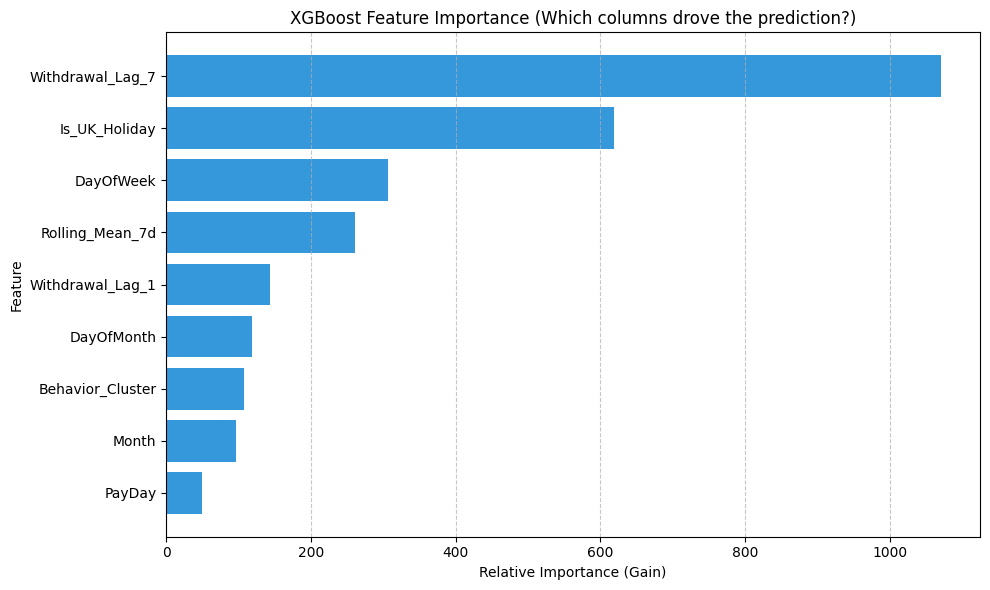

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance_scores = model.get_booster().get_score(importance_type='gain')


importance_df = pd.DataFrame({
    'Feature': importance_scores.keys(),
    'Importance (Gain)': importance_scores.values()
})


importance_df = importance_df.sort_values(by='Importance (Gain)', ascending=True)

# 4. Plot the results!
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance (Gain)'], color='#3498db')
plt.title('XGBoost Feature Importance (Which columns drove the prediction?)')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

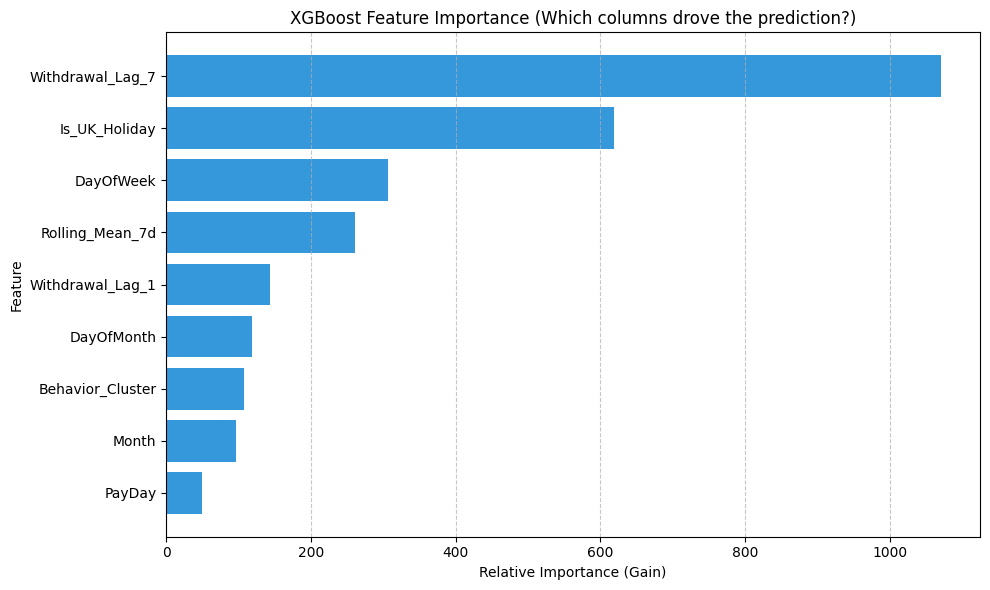

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance_scores = model.get_booster().get_score(importance_type='gain')


importance_df = pd.DataFrame({
    'Feature': importance_scores.keys(),
    'Importance (Gain)': importance_scores.values()
})


importance_df = importance_df.sort_values(by='Importance (Gain)', ascending=True)

# 4. Plot the results!
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance (Gain)'], color='#3498db')
plt.title('XGBoost Feature Importance (Which columns drove the prediction?)')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the menu of options you want to test
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500, 800],
    'subsample': [0.8, 1.0] # Another great setting: uses 80% of data per tree to prevent overfitting
}

# 2. Set up the "Tuner" (using your existing X_train, y_train)
# It will randomly pick 20 combinations from the menu and test them using Cross-Validation
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,          # Test 20 random combinations
    scoring='neg_mean_absolute_error', # We want the lowest MAE
    cv=3,               # Test each combination 3 times
    verbose=1
)

# 3. Start the hunt! (This might take a few minutes)
print("Searching for the perfect hyperparameters...")
random_search.fit(X_train, y_train)

# 4. Reveal the winner
print("Best MAE Score:", -random_search.best_score_)
print("Best Settings:", random_search.best_params_)

Searching for the perfect hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best MAE Score: 2.8284940534680487
Best Settings: {'subsample': 1.0, 'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.05}


In [25]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.6 MB/s  0:00:02 4.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


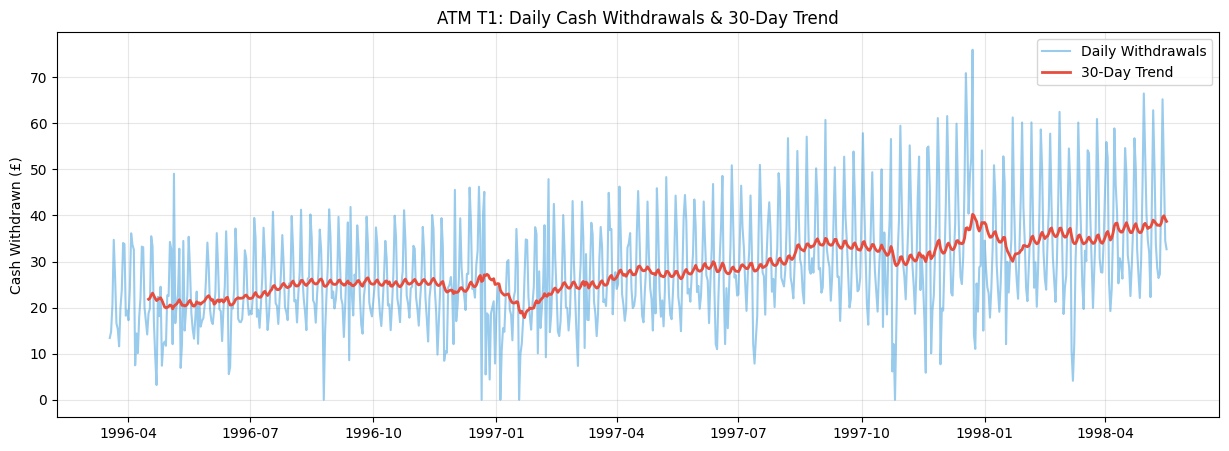

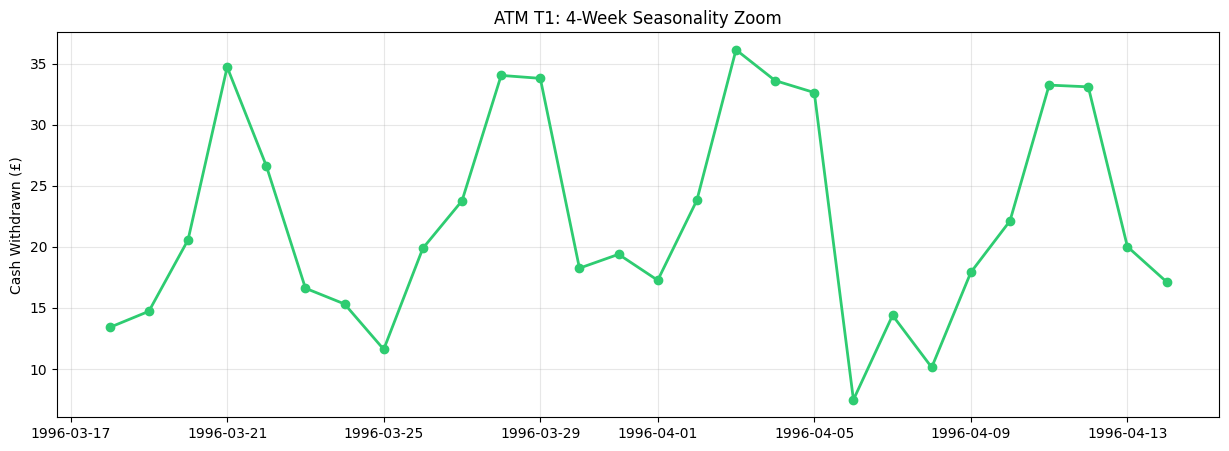

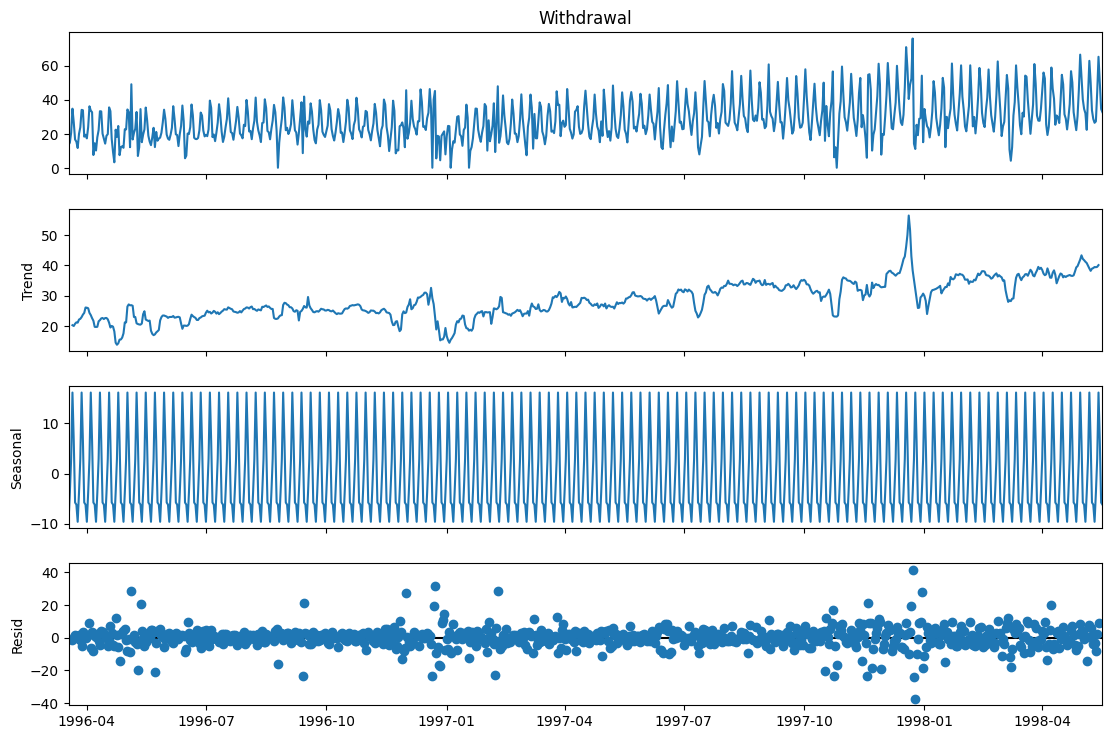

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


atm_id = 'T1' 
atm_data = df_nn5[df_nn5['ATM_ID'] == atm_id].set_index('Date')['Withdrawal']


plt.figure(figsize=(15, 5))

plt.plot(atm_data.index, atm_data.values, label='Daily Withdrawals', color='#3498db', alpha=0.5)


plt.plot(atm_data.index, atm_data.rolling(window=30).mean(), label='30-Day Trend', color='#e74c3c', linewidth=2)

plt.title(f'ATM {atm_id}: Daily Cash Withdrawals & 30-Day Trend')
plt.ylabel('Cash Withdrawn (£)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(15, 5))
zoom_data = atm_data.iloc[:28] 

plt.plot(zoom_data.index, zoom_data.values, marker='o', color='#2ecc71', linewidth=2)
plt.title(f'ATM {atm_id}: 4-Week Seasonality Zoom')
plt.ylabel('Cash Withdrawn (£)')
plt.grid(alpha=0.3)
plt.show()

decomposition = seasonal_decompose(atm_data.dropna(), model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

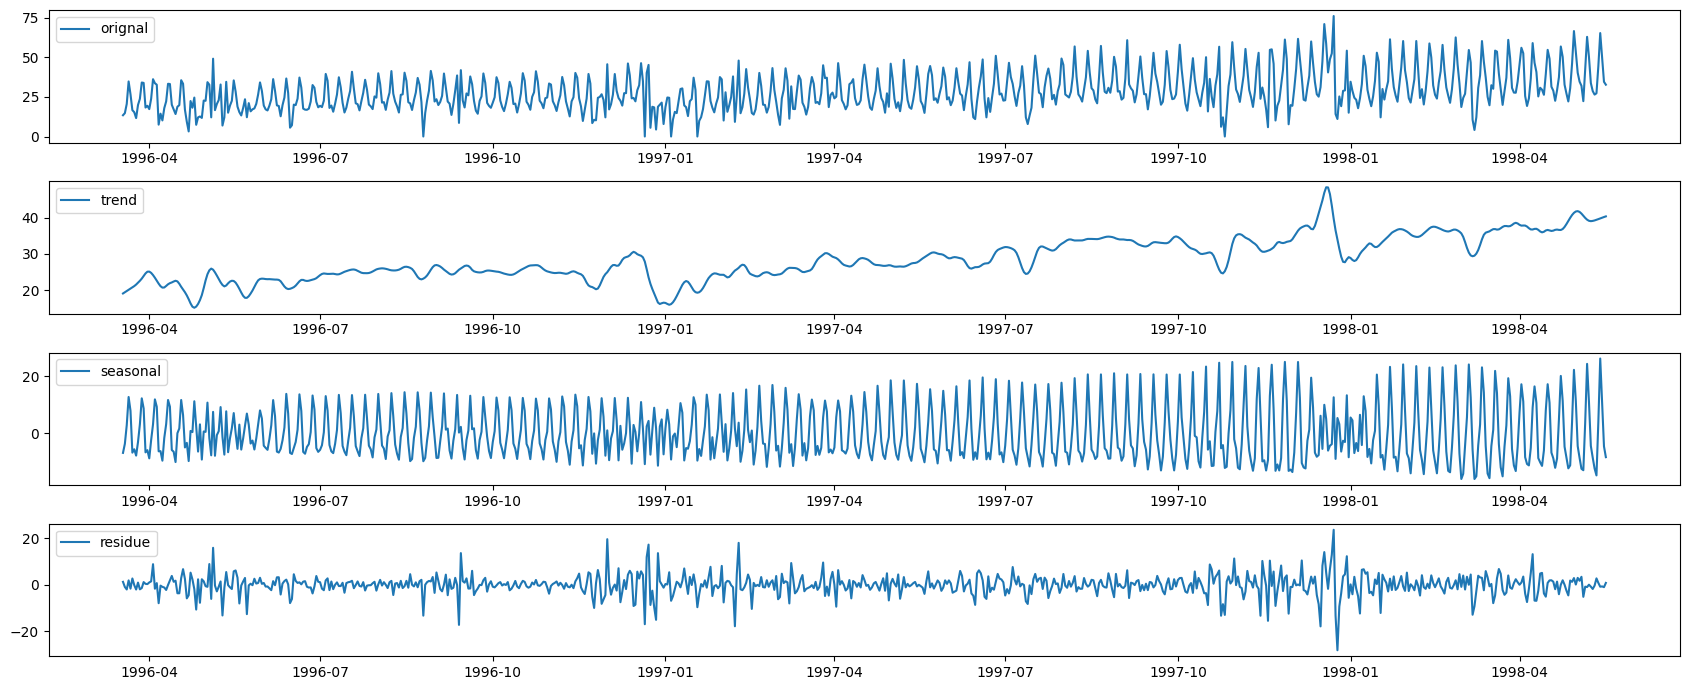

In [44]:
from statsmodels.tsa.seasonal import STL
plt.figure(figsize=(17, 7))
stl_decomposition = STL(atm_data.dropna(), period=7)
fig_1 = stl_decomposition.fit()

plt.subplot(411)
plt.plot(fig_1.observed, label='orignal')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(fig_1.trend, label='trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(fig_1.seasonal, label='seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(fig_1.resid, label='residue')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [70]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(atm_data)
print('p-value',adf_test)

p-value (np.float64(-1.718123097615762), np.float64(0.4217999307608132), 21, 769, {'1%': np.float64(-3.438882201132452), '5%': np.float64(-2.865305765357574), '10%': np.float64(-2.568775270215655)}, np.float64(5282.651325996006))


In [ ]:
!pip install ks

In [69]:
from scipy.stats import ks_2samp
def test(data):
    size = len(data)//2
    first_part = data[:size]
    second_part = data[size:]
    stat, p_value = ks_2samp(first_part, second_part)
    return stat, p_value
stat, p_value = test(atm_data.dropna())
print(f'{p_value:.23f}')

0.00000000000000000001150


In [55]:

df_nn5['Withdrawal_Diff'] = df_nn5.groupby('ATM_ID')['Withdrawal'].diff()


In [60]:
df_nn5.drop(index=0).reset_index(inplace=True)

In [61]:
df_nn5

,Date,ATM_ID,Withdrawal,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay,Behavior_Cluster,Withdrawal_Lag_7,Withdrawal_Lag_1,Rolling_Mean_7d,Withdrawal_Diff
0,1996-03-18,T1,13.407029,0,0,3,18,0,0,3,13.407029,13.407029,13.407029,NaN
1,1996-03-19,T1,14.725057,1,0,3,19,0,0,3,14.725057,13.407029,14.066043,1.318027
2,1996-03-20,T1,20.564059,2,0,3,20,0,0,3,20.564059,14.725057,16.232048,5.839002
3,1996-03-21,T1,34.708050,3,0,3,21,0,0,3,34.708050,20.564059,20.851049,14.143991
4,1996-03-22,T1,26.629819,4,0,3,22,0,0,3,26.629819,34.708050,22.006803,-8.078231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78304,1998-05-13,T99,16.912151,2,0,5,13,0,0,1,15.807470,14.137296,18.054407,2.774855
78305,1998-05-14,T99,24.829037,3,0,5,14,0,0,1,26.038927,16.912151,17.881566,7.916886
78306,1998-05-15,T99,26.196739,4,0,5,15,0,0,1,27.643346,24.829037,17.674908,1.367701
78307,1998-05-16,T99,19.884271,5,1,5,16,0,0,1,16.017885,26.196739,18.227249,-6.312467


In [63]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

weights = np.linspace(0.5, 1.0, len(X_train))

model_weighted = xgb.XGBRegressor(
    max_depth=8,
    learning_rate=0.05,
    n_estimators=800,
    subsample=0.8,
    random_state=42
)

print("Training Tuned XGBoost with Sample Weights...")
model_weighted.fit(X_train, y_train, sample_weight=weights)

predictions_weighted = model_weighted.predict(X_test)

mae_weighted = mean_absolute_error(y_test, predictions_weighted)
print(f"Old MAE: £3.52")
print(f"New Weighted MAE: £{mae_weighted:.2f}")

Training Tuned XGBoost with Sample Weights...
Old MAE: £3.52
New Weighted MAE: £3.52


In [73]:

split_date_xgb = df_model_ready['Date'].max() - pd.Timedelta(days=60)

train_xgb = df_model_ready[df_model_ready['Date'] < split_date_xgb]
test_xgb = df_model_ready[df_model_ready['Date'] >= split_date_xgb]# Calculate the overall mean of the withdrawals
average_withdrawal = model_xgb['Withdrawal'].mean()

mape = (global_mae / average_withdrawal) * 100

print(f"Average Daily ATM Withdrawal: £{average_withdrawal:.2f}")
print(f"Global Error Margin (MAE): £{global_mae:.2f}")
print(f"Final Percentage Error: {mape:.2f}%")
print(f"Overall Model Accuracy: {100 - mape:.2f}%")

NameError: name 'df_model_ready' is not defined